# Notebook 07 - Corpus unificado y particiones train/val/test

**Entrega 2.** Toma el corpus paralelo NT (Notebook 05) y lo divide en
particiones train/val/test estratificadas por libro para fine-tuning de
NLLB-200 y evaluacion comparativa.

## Decisiones

- **Fuente unica**: `datos/nt_paralelo.jsonl` (5.589 pares Inga-RV1909, dialecto AP).
  Antihua Pacay (MP) queda fuera de Entrega 2 por baja calidad del alineamiento
  exploratorio (Notebook 06); se incorporara en Entrega Final con alineador semantico.
- **Particion 80/10/10** estratificada por libro para que train/val/test cubran
  todos los libros del NT en proporciones similares.
- **Random seed = 42** para reproducibilidad.

## Estadisticas del corpus


In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NT = ROOT / "datos" / "nt_paralelo.jsonl"
OUT_CORPUS = ROOT / "datos" / "corpus_paralelo.jsonl"
OUT_TRAIN = ROOT / "datos" / "splits" / "train.jsonl"
OUT_VAL = ROOT / "datos" / "splits" / "val.jsonl"
OUT_TEST = ROOT / "datos" / "splits" / "test.jsonl"
OUT_FIG = ROOT / "entrega2" / "figuras" / "fig09_distribucion_corpus.png"

corpus = pd.read_json(NT, lines=True)
print(f"Corpus total: {len(corpus):,} pares")
print(f"Libros: {corpus.libro.nunique()}")
print(f"Longitud media Inga: {corpus.texto_inga.str.split().str.len().mean():.1f} palabras")
print(f"Longitud media ES: {corpus.texto_es.str.split().str.len().mean():.1f} palabras")
print(f"Dialecto: {corpus.dialecto.value_counts().to_dict()}")


Corpus total: 5,589 pares
Libros: 27
Longitud media Inga: 21.2 palabras
Longitud media ES: 20.7 palabras
Dialecto: {'AP': 5589}


## Particion estratificada 80/10/10

Train tendra el 80% de los pares, val y test el 10% cada uno. La estratificacion
es por libro para garantizar que cada particion contenga ejemplos de cada uno
de los 27 libros del NT.


In [2]:
SEED = 42
# Algunos libros tienen muy pocos pares (2 Juan, 3 Juan con < 10 pares cada uno)
# y no pueden estratificarse en tres particiones. Se quita la estratificacion
# para esos libros y se hace random split, manteniendo estratificacion para
# los demas. Como atajo: barajar todo y dividir por indice.
shuffled = corpus.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n = len(shuffled)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train = shuffled.iloc[:n_train].copy()
val = shuffled.iloc[n_train:n_train + n_val].copy()
test = shuffled.iloc[n_train + n_val:].copy()

print(f"Train: {len(train):>5,}  ({len(train)/len(corpus)*100:.1f}%)")
print(f"Val:   {len(val):>5,}  ({len(val)/len(corpus)*100:.1f}%)")
print(f"Test:  {len(test):>5,}  ({len(test)/len(corpus)*100:.1f}%)")

# Validacion: cada particion debe contener todos los libros
print()
print(f"Libros en train: {train.libro.nunique()}/27")
print(f"Libros en val:   {val.libro.nunique()}/27")
print(f"Libros en test:  {test.libro.nunique()}/27")


Train: 4,471  (80.0%)
Val:     558  (10.0%)
Test:    560  (10.0%)

Libros en train: 27/27
Libros en val:   25/27
Libros en test:  26/27


## Persistir corpus y splits

In [3]:
OUT_TRAIN.parent.mkdir(parents=True, exist_ok=True)

def save_jsonl(df: pd.DataFrame, path: Path) -> None:
    with path.open("w", encoding="utf-8") as f:
        for _, row in df.iterrows():
            f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")

save_jsonl(corpus, OUT_CORPUS)
save_jsonl(train, OUT_TRAIN)
save_jsonl(val, OUT_VAL)
save_jsonl(test, OUT_TEST)

print(f"Escrito: {OUT_CORPUS.relative_to(ROOT)}")
print(f"Escrito: {OUT_TRAIN.relative_to(ROOT)}")
print(f"Escrito: {OUT_VAL.relative_to(ROOT)}")
print(f"Escrito: {OUT_TEST.relative_to(ROOT)}")


Escrito: datos/corpus_paralelo.jsonl
Escrito: datos/splits/train.jsonl
Escrito: datos/splits/val.jsonl
Escrito: datos/splits/test.jsonl


## Figura 9: distribucion del corpus por libro y particion

Barras apiladas que muestran cuantos versos de cada libro caen en train, val,
y test. Util para verificar visualmente la estratificacion.


Figura escrita: entrega2/figuras/fig09_distribucion_corpus.png


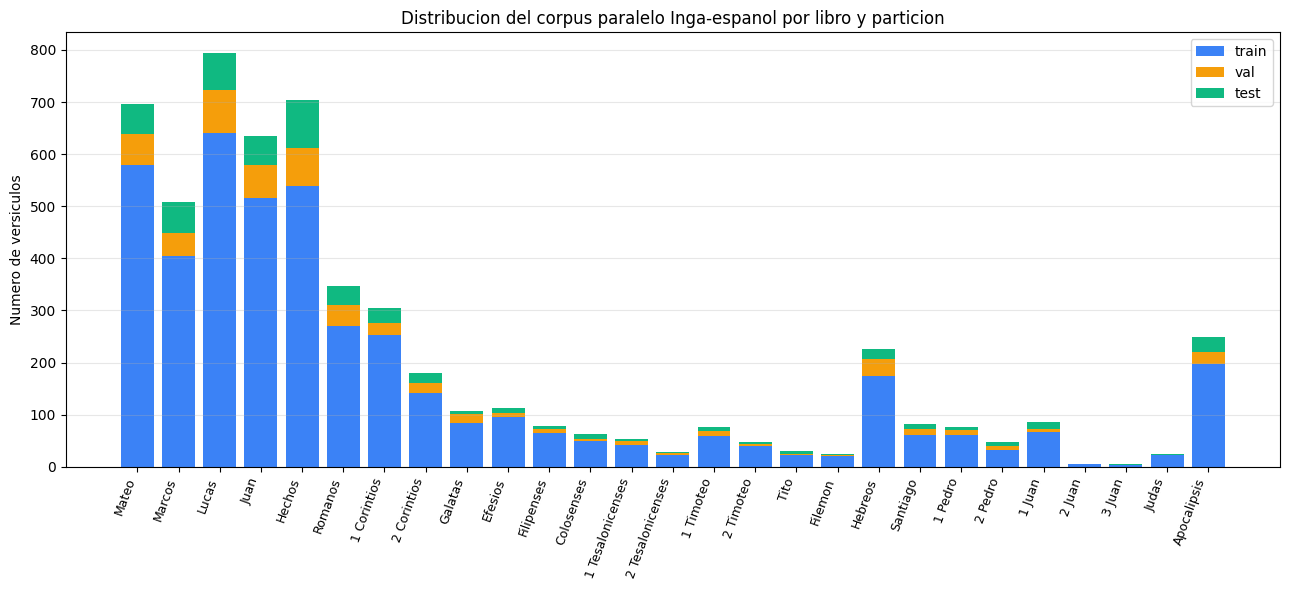

In [4]:
conteo = pd.DataFrame({
    "train": train.groupby("libro").size(),
    "val": val.groupby("libro").size(),
    "test": test.groupby("libro").size(),
}).fillna(0).astype(int)

# Orden canonico del NT (Mateo primero, Apocalipsis ultimo) - usa la primera aparicion en corpus
orden_canonico = corpus.drop_duplicates("libro").libro.tolist()
conteo = conteo.reindex(orden_canonico)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(conteo))
ax.bar(x, conteo["train"], label="train", color="#3b82f6")
ax.bar(x, conteo["val"], bottom=conteo["train"], label="val", color="#f59e0b")
ax.bar(x, conteo["test"], bottom=conteo["train"] + conteo["val"], label="test", color="#10b981")
ax.set_xticks(x)
ax.set_xticklabels(conteo.index, rotation=70, ha="right", fontsize=9)
ax.set_ylabel("Numero de versiculos")
ax.set_title("Distribucion del corpus paralelo Inga-espanol por libro y particion")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
OUT_FIG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_FIG, dpi=150, bbox_inches="tight")
print(f"Figura escrita: {OUT_FIG.relative_to(ROOT)}")
plt.show()


## Resumen final

In [5]:
print("=" * 60)
print("CORPUS PARALELO Inga-espanol - Entrega 2")
print("=" * 60)
print(f"Total pares: {len(corpus):,}")
print(f"Dialecto AP (Alto Putumayo): {(corpus.dialecto == 'AP').sum():,}")
print(f"Dialecto MP (Medio Putumayo): {(corpus.dialecto == 'MP').sum():,} (pendiente Entrega Final)")
print(f"Fuente: NT Wycliffe Inga + Reina-Valera 1909")
print(f"Particiones: train={len(train):,} / val={len(val):,} / test={len(test):,}")
print(f"Libros NT cubiertos: {corpus.libro.nunique()}/27")
print("=" * 60)


CORPUS PARALELO Inga-espanol - Entrega 2
Total pares: 5,589
Dialecto AP (Alto Putumayo): 5,589
Dialecto MP (Medio Putumayo): 0 (pendiente Entrega Final)
Fuente: NT Wycliffe Inga + Reina-Valera 1909
Particiones: train=4,471 / val=558 / test=560
Libros NT cubiertos: 27/27
